In [1]:
import matplotlib.pylab as plt
from astropy.io import fits

In [2]:
f356w = fits.open('/Users/sshapiro/Desktop/356w DATA.fits')

In [3]:
f356w['SCI'].data.shape

(2505, 5639)

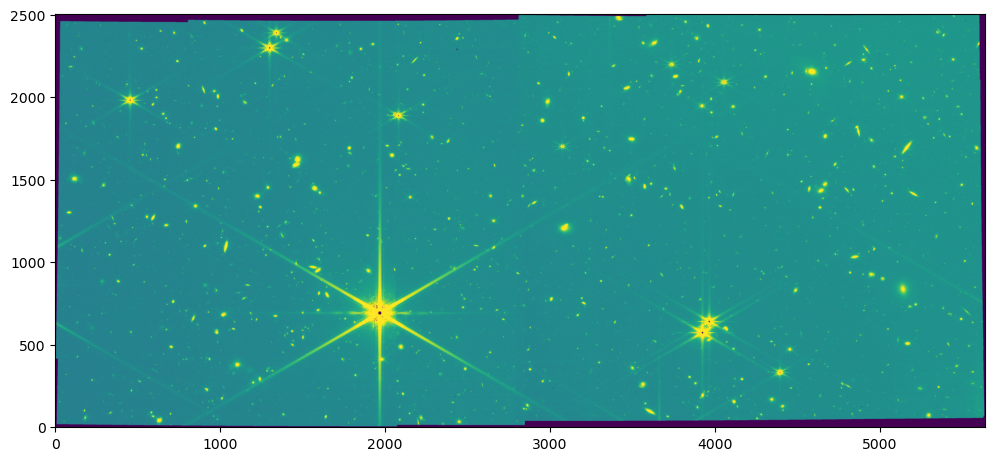

In [4]:
from astropy.visualization import simple_norm
plt.figure(figsize = [12,12])
norm = simple_norm(f356w['SCI'].data, 'asinh', percent = 99)

plt.imshow(f356w['SCI'].data, origin = 'lower', norm = norm, cmap = 'viridis')

In [5]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
sigma_clip = SigmaClip(sigma=4.5)
bkg_estimator = MedianBackground()
bkg = Background2D(f356w['SCI'].data, (200, 200), filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

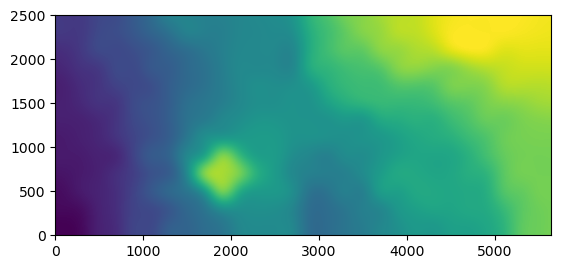

In [6]:
plt.imshow(bkg.background, origin='lower', interpolation='nearest')

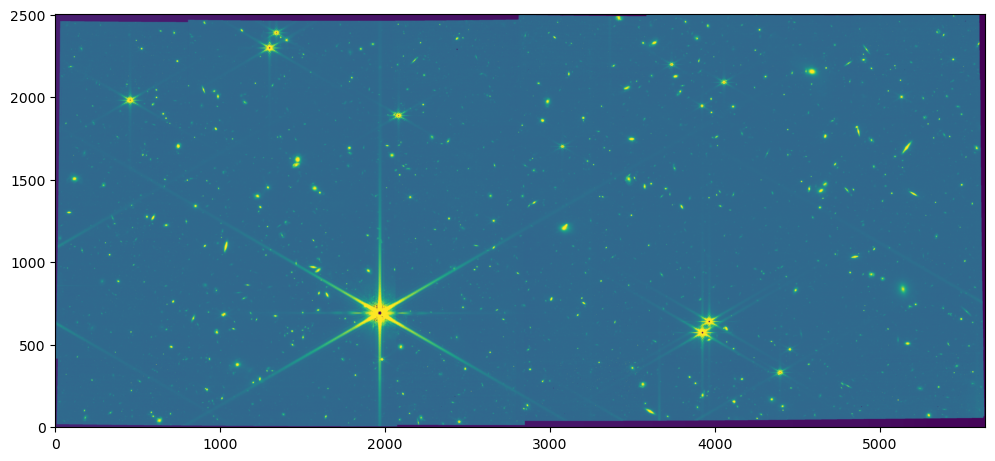

In [7]:
from astropy.visualization import simple_norm
plt.figure(figsize = [12,12])
norm = simple_norm(f356w['SCI'].data - bkg.background, 'asinh', percent = 99.5)

plt.imshow(f356w['SCI'].data - bkg.background, origin = 'lower', norm = norm, cmap = 
          'viridis')

In [1]:
from jdaviz import Imviz
imviz = Imviz()
imviz.show()
imviz.load_data('/Users/sshapiro/Desktop/356w DATA.fits', data_label='356w')

Application(config='imviz', docs_link='https://jdaviz.readthedocs.io/en/v4.2.2/imviz/index.html', events=['cal…